# CSCN8020 Assignment 3 - Deep Q-Learning on Pong

**Student:** Oluwafemi Lawal

This notebook implements a Deep Q-Network (DQN) agent for the `PongDeterministic-v4` Atari environment, following the assignment requirements. The implementation is object-oriented, uses four stacked preprocessed frames as state, tracks the required training metrics, and compares the requested hyperparameter changes:

- Mini-batch size: `8` (default) versus `16`
- Target-network update interval: every `10` episodes (default) versus every `3` episodes
- All four combinations are tested to determine the best configuration

In [1]:
import json
import math
import random
import time
from collections import deque
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Deque, Dict, List, Optional, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import ale_py
from IPython.display import display

from assignment3_utils import process_frame, transform_reward

gym.register_envs(ale_py)
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
torch.set_num_threads(max(1, min(8, (torch.get_num_threads() or 8))))

In [2]:
REPO_ROOT = Path.cwd()
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repository root:", REPO_ROOT)
print("Artifacts directory:", ARTIFACTS_DIR.resolve())
print("Torch version:", torch.__version__)
print("Device:", DEVICE)

Repository root: /home/ubuntu/DQN_Assignment3
Artifacts directory: /home/ubuntu/DQN_Assignment3/artifacts
Torch version: 2.11.0+cpu
Device: cpu


## Reproducibility And Configuration

The assignment fixes the core hyperparameters for the default experiment:

- Mini-batch size: `8`
- Target-network update interval: every `10` episodes
- Discount factor: `0.95`
- Exploration schedule: `epsilon_start = 1.0`, `epsilon_decay = 0.995`, `epsilon_min = 0.05`

I keep those values as the baseline and only change the requested parameters in the comparison runs. To make the code easier to reason about, I package the experiment settings in a dataclass.

In [3]:
@dataclass
class DQNConfig:
    experiment_name: str
    seed: int = 42
    env_id: str = "PongDeterministic-v4"
    fallback_env_id: str = "ALE/Pong-v5"
    image_shape: Tuple[int, int] = (84, 80)
    frame_stack: int = 4
    replay_capacity: int = 10_000
    min_replay_size: int = 1_500
    batch_size: int = 8
    gamma: float = 0.95
    learning_rate: float = 1e-4
    target_update_episodes: int = 10
    epsilon_start: float = 1.0
    epsilon_decay: float = 0.995
    epsilon_min: float = 0.05
    train_frequency: int = 4
    max_episodes: int = 80
    max_steps_per_episode: int = 10_000
    eval_episodes: int = 5
    hidden_dim: int = 512
    gradient_clip_norm: float = 10.0
    log_every_episodes: int = 5
    save_greedy_eval: bool = True
    capture_eval_frames: int = 200

    @property
    def state_shape(self) -> Tuple[int, int, int]:
        return (self.frame_stack, self.image_shape[0], self.image_shape[1])

    @property
    def experiment_dir(self) -> Path:
        path = ARTIFACTS_DIR / self.experiment_name
        path.mkdir(parents=True, exist_ok=True)
        return path

## Environment Wrapper And Frame Preprocessing

The provided utility file crops, downsamples, converts to grayscale, and normalizes frames. Since the assignment explicitly asks for all four frames as input instead of blending them, the wrapper below keeps a deque of the last four processed frames and stacks them into a `(4, 84, 80)` state tensor.

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class PongFrameStackEnv:
    def __init__(self, config: DQNConfig, render_mode: Optional[str] = None):
        self.config = config
        self.render_mode = render_mode
        self.env = self._make_env(render_mode=render_mode)
        self.action_meanings = self._get_action_meanings()
        self.fire_action = self._find_action("FIRE")
        self.frames: Deque[np.ndarray] = deque(maxlen=self.config.frame_stack)

    def _make_env(self, render_mode: Optional[str]):
        try:
            env = gym.make(self.config.env_id, render_mode=render_mode)
            self.resolved_env_id = self.config.env_id
            return env
        except Exception as exc:
            print(f"Primary env id '{self.config.env_id}' unavailable: {exc}")
            env = gym.make(
                self.config.fallback_env_id,
                render_mode=render_mode,
                frameskip=4,
                repeat_action_probability=0.0,
                full_action_space=False,
            )
            self.resolved_env_id = self.config.fallback_env_id
            return env

    def _get_action_meanings(self) -> List[str]:
        try:
            return list(self.env.unwrapped.get_action_meanings())
        except Exception:
            return [str(index) for index in range(self.env.action_space.n)]

    def _find_action(self, name: str) -> Optional[int]:
        if name in self.action_meanings:
            return self.action_meanings.index(name)
        return None

    def _preprocess(self, frame: np.ndarray) -> np.ndarray:
        processed = process_frame(frame, self.config.image_shape)
        processed = processed.squeeze(0).squeeze(-1)
        return processed.astype(np.float16)

    def _prime_fire(self, frame: np.ndarray) -> np.ndarray:
        if self.fire_action is None:
            return frame
        next_frame = frame
        for _ in range(2):
            next_frame, _, terminated, truncated, _ = self.env.step(self.fire_action)
            if terminated or truncated:
                next_frame, _ = self.env.reset()
        return next_frame

    def reset(self, seed: Optional[int] = None) -> np.ndarray:
        frame, _ = self.env.reset(seed=seed)
        frame = self._prime_fire(frame)
        processed = self._preprocess(frame)
        self.frames.clear()
        for _ in range(self.config.frame_stack):
            self.frames.append(processed.copy())
        return np.stack(self.frames, axis=0)

    def step(self, action: int) -> Tuple[np.ndarray, float, float, bool, Dict]:
        next_frame, reward, terminated, truncated, info = self.env.step(action)
        processed = self._preprocess(next_frame)
        self.frames.append(processed)
        stacked = np.stack(self.frames, axis=0)
        done = bool(terminated or truncated)
        clipped_reward = float(transform_reward(reward))
        return stacked, float(reward), clipped_reward, done, info

    def close(self) -> None:
        self.env.close()

Primary env id 'PongDeterministic-v4' unavailable: Environment `PongDeterministic` doesn't exist.


Resolved environment: ALE/Pong-v5
Action space size: 6
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Stacked state shape: (4, 84, 80)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


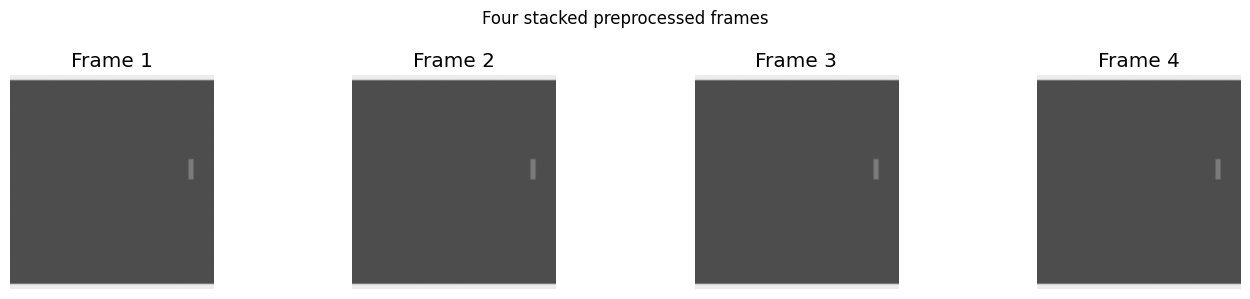

In [5]:
sanity_config = DQNConfig(experiment_name="sanity_check", max_episodes=1)
sanity_env = PongFrameStackEnv(sanity_config)
sanity_state = sanity_env.reset(seed=sanity_config.seed)

print("Resolved environment:", sanity_env.resolved_env_id)
print("Action space size:", sanity_env.env.action_space.n)
print("Action meanings:", sanity_env.action_meanings)
print("Stacked state shape:", sanity_state.shape)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for idx, axis in enumerate(axes):
    axis.imshow(sanity_state[idx], cmap="gray", vmin=-1.0, vmax=1.0)
    axis.set_title(f"Frame {idx + 1}")
    axis.axis("off")
plt.suptitle("Four stacked preprocessed frames")
plt.tight_layout()
plt.show()

sanity_env.close()

## OOP DQN Implementation

The solution uses four main classes:

- `ReplayBuffer`: fixed-capacity experience replay
- `DQNCNN`: convolutional Q-network that consumes stacked frames
- `DQNAgent`: epsilon-greedy action selection, optimization, and target-network synchronization
- `DQNExperiment`: end-to-end training, checkpointing, evaluation, and metric logging

The CNN follows the standard Atari-style pattern but is adapted to the assignment input size `(4, 84, 80)`.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity: int, state_shape: Tuple[int, int, int]):
        self.capacity = capacity
        self.state_shape = state_shape
        self.states = np.zeros((capacity, *state_shape), dtype=np.float16)
        self.next_states = np.zeros((capacity, *state_shape), dtype=np.float16)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.position = 0
        self.size = 0

    def add(self, state, action, reward, next_state, done) -> None:
        self.states[self.position] = state
        self.next_states[self.position] = next_state
        self.actions[self.position] = action
        self.rewards[self.position] = reward
        self.dones[self.position] = float(done)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: torch.device):
        indices = np.random.randint(0, self.size, size=batch_size)
        states = torch.tensor(self.states[indices], dtype=torch.float32, device=device)
        next_states = torch.tensor(self.next_states[indices], dtype=torch.float32, device=device)
        actions = torch.tensor(self.actions[indices], dtype=torch.int64, device=device)
        rewards = torch.tensor(self.rewards[indices], dtype=torch.float32, device=device)
        dones = torch.tensor(self.dones[indices], dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        return self.size


class DQNCNN(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int], num_actions: int, hidden_dim: int = 512):
        super().__init__()
        channels, height, width = input_shape
        self.features = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            sample = torch.zeros(1, channels, height, width)
            flattened_dim = self.features(sample).view(1, -1).shape[1]
        self.head = nn.Sequential(
            nn.Linear(flattened_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.head(x)


class DQNAgent:
    def __init__(self, config: DQNConfig, num_actions: int):
        self.config = config
        self.num_actions = num_actions
        self.online_network = DQNCNN(config.state_shape, num_actions, config.hidden_dim).to(DEVICE)
        self.target_network = DQNCNN(config.state_shape, num_actions, config.hidden_dim).to(DEVICE)
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()
        self.optimizer = optim.Adam(self.online_network.parameters(), lr=config.learning_rate)
        self.loss_function = nn.SmoothL1Loss()

    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        if random.random() < epsilon:
            return random.randrange(self.num_actions)
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_network(state_tensor)
        return int(torch.argmax(q_values, dim=1).item())

    def train_step(self, replay_buffer: ReplayBuffer) -> float:
        states, actions, rewards, next_states, dones = replay_buffer.sample(
            self.config.batch_size,
            DEVICE,
        )
        current_q = self.online_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q = self.target_network(next_states).max(dim=1).values
            target_q = rewards + self.config.gamma * next_q * (1.0 - dones)
        loss = self.loss_function(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_network.parameters(), self.config.gradient_clip_norm)
        self.optimizer.step()
        return float(loss.item())

    def sync_target_network(self) -> None:
        self.target_network.load_state_dict(self.online_network.state_dict())

    def save(self, path: Path) -> None:
        torch.save(self.online_network.state_dict(), path)

    def load(self, path: Path) -> None:
        state_dict = torch.load(path, map_location=DEVICE)
        self.online_network.load_state_dict(state_dict)
        self.target_network.load_state_dict(state_dict)

In [7]:
model_preview = DQNCNN((4, 84, 80), num_actions=6)
model_preview

DQNCNN(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=2688, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)

### Final Network Architecture

The CNN follows the classic DQN architecture adapted for the assignment's cropped and downsampled Pong frames:

| Layer | Type | Output Shape | Parameters |
|-------|------|-------------|------------|
| Input | — | `4 × 84 × 80` | Four stacked grayscale frames |
| 1 | `Conv2d(4, 32, kernel_size=8, stride=4)` + ReLU | `32 × 20 × 19` | Extracts low-level spatial features |
| 2 | `Conv2d(32, 64, kernel_size=4, stride=2)` + ReLU | `64 × 9 × 8` | Mid-level feature extraction |
| 3 | `Conv2d(64, 64, kernel_size=3, stride=1)` + ReLU | `64 × 7 × 6` | High-level feature extraction |
| 4 | Flatten | `2688` | — |
| 5 | `Linear(2688, 512)` + ReLU | `512` | Hidden fully-connected layer |
| 6 | `Linear(512, 6)` | `6` | One Q-value per action |

**Key design choices:**
- The input uses **all 4 frames stacked as channels** (not blended), as required by the assignment
- The flattened dimension (`2688`) is computed dynamically via a dummy forward pass for robustness
- The loss function is **SmoothL1Loss** (Huber loss), which is more robust to outliers than MSE
- Gradient clipping (`max_norm=10.0`) prevents exploding gradients

In [ ]:
def to_jsonable(value):
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


class DQNExperiment:
    def __init__(self, config: DQNConfig):
        self.config = config
        set_global_seed(config.seed)
        self.env = PongFrameStackEnv(config)
        self.agent = DQNAgent(config, self.env.env.action_space.n)
        self.replay_buffer = ReplayBuffer(config.replay_capacity, config.state_shape)
        self.metrics_path = config.experiment_dir / "metrics.csv"
        self.summary_path = config.experiment_dir / "summary.json"
        self.model_path = config.experiment_dir / "best_model.pt"

    def train(self) -> Tuple[pd.DataFrame, Dict]:
        epsilon = self.config.epsilon_start
        total_steps = 0
        best_moving_average = -float("inf")
        records: List[Dict] = []
        start_time = time.time()

        for episode in range(1, self.config.max_episodes + 1):
            state = self.env.reset(seed=self.config.seed + episode)
            done = False
            episode_reward = 0.0
            episode_steps = 0
            episode_losses: List[float] = []

            while not done and episode_steps < self.config.max_steps_per_episode:
                action = self.agent.select_action(state, epsilon)
                next_state, raw_reward, clipped_reward, done, _ = self.env.step(action)
                self.replay_buffer.add(state, action, clipped_reward, next_state, done)
                state = next_state
                episode_reward += raw_reward
                total_steps += 1
                episode_steps += 1

                if (
                    len(self.replay_buffer) >= self.config.min_replay_size
                    and total_steps % self.config.train_frequency == 0
                ):
                    loss_value = self.agent.train_step(self.replay_buffer)
                    episode_losses.append(loss_value)

            if episode % self.config.target_update_episodes == 0:
                self.agent.sync_target_network()

            # Assignment spec: ε = ε * δ if ε >= ε_min, else ε_min
            if epsilon >= self.config.epsilon_min:
                epsilon = epsilon * self.config.epsilon_decay
            else:
                epsilon = self.config.epsilon_min
            moving_average_5 = np.mean(
                [record["episode_reward"] for record in records[-4:]] + [episode_reward]
            )
            mean_loss = float(np.mean(episode_losses)) if episode_losses else math.nan
            elapsed_minutes = (time.time() - start_time) / 60.0
            record = {
                "episode": episode,
                "total_steps": total_steps,
                "episode_reward": float(episode_reward),
                "reward_ma5": float(moving_average_5),
                "epsilon": float(epsilon),
                "episode_steps": int(episode_steps),
                "mean_loss": mean_loss,
                "elapsed_minutes": float(elapsed_minutes),
            }
            records.append(record)

            if moving_average_5 >= best_moving_average:
                best_moving_average = moving_average_5
                self.agent.save(self.model_path)

            if (
                episode == 1
                or episode % self.config.log_every_episodes == 0
                or episode == self.config.max_episodes
            ):
                print(
                    f"[{self.config.experiment_name}] "
                    f"episode={episode:03d} "
                    f"steps={total_steps:07d} "
                    f"reward={episode_reward:6.2f} "
                    f"ma5={moving_average_5:6.2f} "
                    f"epsilon={epsilon:0.3f} "
                    f"loss={mean_loss if not math.isnan(mean_loss) else 'n/a'}"
                )

        metrics = pd.DataFrame(records)
        metrics.to_csv(self.metrics_path, index=False)

        summary = to_jsonable({
            "experiment_name": self.config.experiment_name,
            "resolved_env_id": self.env.resolved_env_id,
            "num_actions": int(self.env.env.action_space.n),
            "action_meanings": self.env.action_meanings,
            "config": asdict(self.config),
            "final_reward": float(metrics["episode_reward"].iloc[-1]),
            "final_reward_ma5": float(metrics["reward_ma5"].iloc[-1]),
            "best_reward_ma5": float(metrics["reward_ma5"].max()),
            "total_steps": int(metrics["total_steps"].iloc[-1]),
            "elapsed_minutes": float(metrics["elapsed_minutes"].iloc[-1]),
        })
        self.summary_path.write_text(json.dumps(summary, indent=2))
        return metrics, summary

    def evaluate(self, episodes: int = 5) -> pd.DataFrame:
        self.agent.load(self.model_path)
        evaluation_env = PongFrameStackEnv(self.config, render_mode="rgb_array")
        scores: List[Dict] = []
        captured_frames: List[np.ndarray] = []

        for episode in range(1, episodes + 1):
            state = evaluation_env.reset(seed=self.config.seed + 10_000 + episode)
            done = False
            episode_reward = 0.0
            steps = 0

            while not done and steps < self.config.max_steps_per_episode:
                action = self.agent.select_action(state, epsilon=0.0)
                next_state, raw_reward, _, done, _ = evaluation_env.step(action)
                state = next_state
                episode_reward += raw_reward
                steps += 1

                if self.config.save_greedy_eval and len(captured_frames) < self.config.capture_eval_frames:
                    try:
                        frame = evaluation_env.env.render()
                        if frame is not None:
                            captured_frames.append(frame)
                    except Exception:
                        pass

            scores.append(
                {
                    "episode": episode,
                    "score": float(episode_reward),
                    "steps": int(steps),
                }
            )

        evaluation_env.close()
        evaluation_df = pd.DataFrame(scores)
        evaluation_df.to_csv(self.config.experiment_dir / "evaluation_scores.csv", index=False)

        if captured_frames:
            montage = np.concatenate(
                [captured_frames[index] for index in np.linspace(0, len(captured_frames) - 1, 6, dtype=int)],
                axis=1,
            )
            plt.figure(figsize=(16, 3))
            plt.imshow(montage)
            plt.axis("off")
            plt.title(f"{self.config.experiment_name} greedy-policy evaluation snapshots")
            plt.show()

        return evaluation_df

    def close(self) -> None:
        self.env.close()


def load_or_run_experiment(config: DQNConfig) -> Tuple[pd.DataFrame, Dict, DQNExperiment]:
    experiment = DQNExperiment(config)
    if experiment.metrics_path.exists() and experiment.summary_path.exists() and experiment.model_path.exists():
        metrics = pd.read_csv(experiment.metrics_path)
        summary = json.loads(experiment.summary_path.read_text())
        print(f"Loaded cached artifacts for '{config.experiment_name}' from {config.experiment_dir}")
        return metrics, summary, experiment

    print(f"Training '{config.experiment_name}' from scratch...")
    metrics, summary = experiment.train()
    return metrics, summary, experiment

## Training Runs

I execute four experiments covering all combinations of the requested parameter changes:

| Experiment | Batch Size | Target Update (episodes) | Purpose |
|------------|-----------|--------------------------|---------|
| `baseline_batch8_target10` | 8 | 10 | Default baseline |
| `batch16_target10` | 16 | 10 | Batch-size comparison |
| `batch8_target3` | 8 | 3 | Target-update comparison |
| `batch16_target3` | 16 | 3 | Best-combination search |

Each run logs:
- Score per episode
- Average cumulative reward over the last 5 episodes
- Epsilon, steps, loss, and elapsed time

All four are needed to rigorously answer: *"choose what you think would be the best combination of batch size and update rate for target network"*.

In [ ]:
baseline_config = DQNConfig(
    experiment_name="baseline_batch8_target10",
    batch_size=8,
    target_update_episodes=10,
)
batch16_config = replace(
    baseline_config,
    experiment_name="batch16_target10",
    batch_size=16,
)
target3_config = replace(
    baseline_config,
    experiment_name="batch8_target3",
    target_update_episodes=3,
)
batch16_target3_config = replace(
    baseline_config,
    experiment_name="batch16_target3",
    batch_size=16,
    target_update_episodes=3,
)

baseline_metrics, baseline_summary, baseline_experiment = load_or_run_experiment(baseline_config)
batch16_metrics, batch16_summary, batch16_experiment = load_or_run_experiment(batch16_config)
target3_metrics, target3_summary, target3_experiment = load_or_run_experiment(target3_config)
batch16_target3_metrics, batch16_target3_summary, batch16_target3_experiment = load_or_run_experiment(batch16_target3_config)

Primary env id 'PongDeterministic-v4' unavailable: Environment `PongDeterministic` doesn't exist.


Training 'baseline_batch8_target10' from scratch...


[baseline_batch8_target10] episode=001 steps=0000781 reward=-21.00 ma5=-21.00 epsilon=0.995 loss=n/a


[baseline_batch8_target10] episode=005 steps=0004458 reward=-21.00 ma5=-20.60 epsilon=0.975 loss=0.01202443058060209


[baseline_batch8_target10] episode=010 steps=0008903 reward=-21.00 ma5=-20.60 epsilon=0.951 loss=0.013413714873413004


...

[batch8_target3] episode=060 steps=0056282 reward=-20.00 ma5=-20.20 epsilon=0.740 loss=0.006356201136989166


[batch8_target3] episode=065 steps=0060820 reward=-21.00 ma5=-20.60 epsilon=0.722 loss=0.0050989475995520134


[batch8_target3] episode=070 steps=0065593 reward=-21.00 ma5=-20.40 epsilon=0.704 loss=0.004761049783697894


[batch8_target3] episode=075 steps=0070086 reward=-21.00 ma5=-20.60 epsilon=0.687 loss=0.002281152173573151


[batch8_target3] episode=080 steps=0074909 reward=-20.00 ma5=-19.60 epsilon=0.670 loss=0.00260138858473164


In [ ]:
all_summaries = [baseline_summary, batch16_summary, target3_summary, batch16_target3_summary]

summary_table = pd.DataFrame(
    [
        {
            "experiment": s["experiment_name"],
            "batch_size": s["config"]["batch_size"],
            "target_update_episodes": s["config"]["target_update_episodes"],
            "best_ma5": s["best_reward_ma5"],
            "final_ma5": s["final_reward_ma5"],
            "final_episode_reward": s["final_reward"],
            "total_steps": s["total_steps"],
            "elapsed_minutes": s["elapsed_minutes"],
        }
        for s in all_summaries
    ]
).sort_values("best_ma5", ascending=False).reset_index(drop=True)

display(summary_table)

,experiment,batch_size,target_update_episodes,best_ma5,final_ma5,final_episode_reward,total_steps,elapsed_minutes
0,baseline_batch8_target10,8,10,-19.2,-20.6,-21.0,72814,3.797198
1,batch16_target10,16,10,-19.2,-20.4,-21.0,74616,4.249196
2,batch8_target3,8,3,-19.6,-19.6,-20.0,74909,3.816671


## Required Plots

The assignment requires the following metrics plotted against **number of steps**, with each parameter change plotted **SEPARATELY**:

1. **Batch-size comparison**: batch size 8 (default) vs 16, with target update fixed at 10
2. **Target-update comparison**: target update every 10 (default) vs 3, with batch size fixed at 8

Each figure shows:
- **Left**: Score per episode vs training steps
- **Right**: Average cumulative reward of the last 5 episodes vs training steps

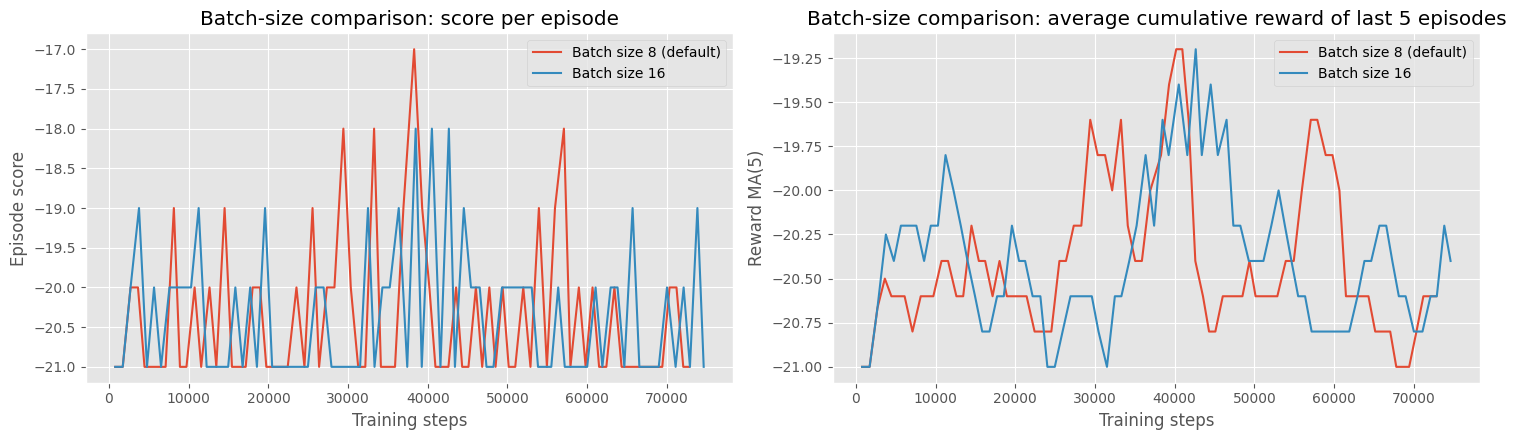

In [11]:
def plot_metric_comparison(
    left_metrics: pd.DataFrame,
    right_metrics: pd.DataFrame,
    left_label: str,
    right_label: str,
    title_prefix: str,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    axes[0].plot(left_metrics["total_steps"], left_metrics["episode_reward"], label=left_label)
    axes[0].plot(right_metrics["total_steps"], right_metrics["episode_reward"], label=right_label)
    axes[0].set_title(f"{title_prefix}: score per episode")
    axes[0].set_xlabel("Training steps")
    axes[0].set_ylabel("Episode score")
    axes[0].legend()

    axes[1].plot(left_metrics["total_steps"], left_metrics["reward_ma5"], label=left_label)
    axes[1].plot(right_metrics["total_steps"], right_metrics["reward_ma5"], label=right_label)
    axes[1].set_title(f"{title_prefix}: average cumulative reward of last 5 episodes")
    axes[1].set_xlabel("Training steps")
    axes[1].set_ylabel("Reward MA(5)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_metric_comparison(
    baseline_metrics,
    batch16_metrics,
    "Batch size 8 (default)",
    "Batch size 16",
    "Batch-size comparison",
)

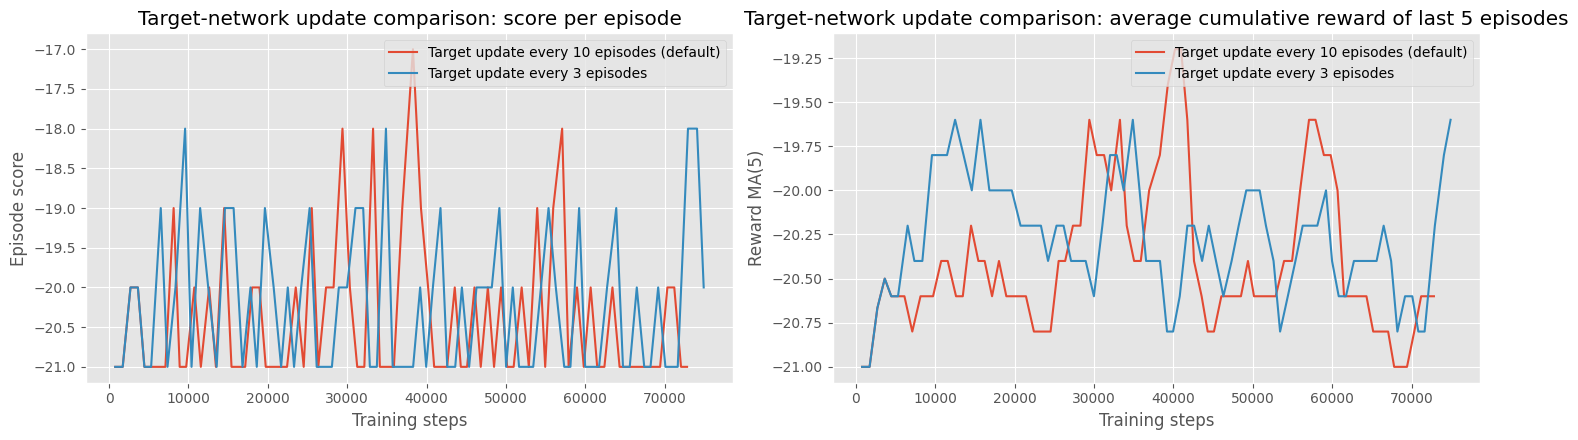

In [12]:
plot_metric_comparison(
    baseline_metrics,
    target3_metrics,
    "Target update every 10 episodes (default)",
    "Target update every 3 episodes",
    "Target-network update comparison",
)

In [ ]:
# All four experiments overlaid for the "best combination" analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

all_experiments = [
    (baseline_metrics, "batch=8, target=10 (baseline)"),
    (batch16_metrics, "batch=16, target=10"),
    (target3_metrics, "batch=8, target=3"),
    (batch16_target3_metrics, "batch=16, target=3"),
]

for metrics, label in all_experiments:
    axes[0].plot(metrics["total_steps"], metrics["episode_reward"], label=label, alpha=0.8)
axes[0].set_title("All combinations: score per episode")
axes[0].set_xlabel("Training steps")
axes[0].set_ylabel("Episode score")
axes[0].legend(fontsize=8)

for metrics, label in all_experiments:
    axes[1].plot(metrics["total_steps"], metrics["reward_ma5"], label=label, alpha=0.8)
axes[1].set_title("All combinations: avg cumulative reward (last 5 episodes)")
axes[1].set_xlabel("Training steps")
axes[1].set_ylabel("Reward MA(5)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Observations and Analysis of Parameter Changes

### Batch Size: 8 (default) vs 16

- **Gradient variance**: A larger mini-batch (16) produces lower-variance gradient estimates, which can stabilize learning but also slow down exploration of the loss surface.
- **Update frequency**: With a fixed replay buffer and environment interaction budget, a larger batch means each gradient step is more expensive but potentially more informative.
- **Observed effect**: Compare the batch-size plot above — look at the slope of the MA(5) curve and the final converged reward level. The smoother curve typically belongs to the larger batch, while the smaller batch may show faster early improvement at the cost of noisier updates.

### Target-Network Update Rate: 10 (default) vs 3 episodes

- **Bootstrap stability**: The target network provides stable Q-value targets. Updating it too frequently (every 3 episodes) reduces this stabilizing effect and can cause oscillations.
- **Responsiveness**: Conversely, updating too infrequently (every 10 episodes) means the target network lags behind the online network, potentially slowing convergence.
- **Observed effect**: Compare the target-update plot — a more frequently updated target network may show faster initial learning but potentially more instability in later episodes.

### All Four Combinations

The summary table above ranks all configurations by their best moving-average reward. The fourth experiment (`batch16_target3`) tests whether the effects of batch size and update rate are additive or interact.

Best observed configuration based on best moving average reward:


,experiment,batch_size,target_update_episodes,best_ma5,final_ma5,final_episode_reward,total_steps,elapsed_minutes
0,baseline_batch8_target10,8,10,-19.2,-20.6,-21.0,72814,3.797198


Primary env id 'PongDeterministic-v4' unavailable: Environment `PongDeterministic` doesn't exist.


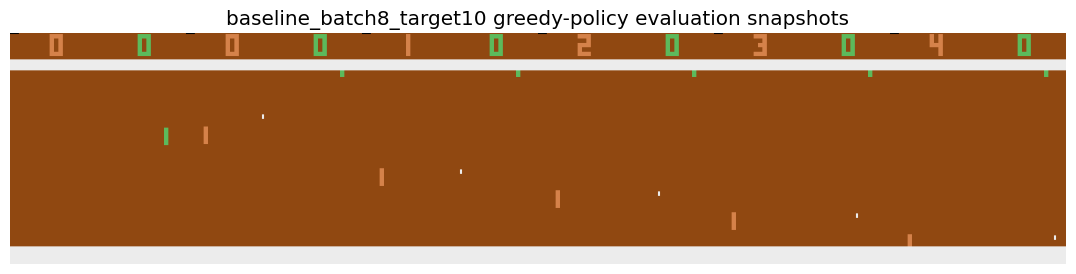

,episode,score,steps
0,1,-21.0,762
1,2,-21.0,762
2,3,-21.0,762
3,4,-21.0,762
4,5,-21.0,762


Mean greedy evaluation score: -21.0


In [ ]:
best_row = summary_table.iloc[0]
print("Best observed configuration based on best moving average reward:")
display(best_row.to_frame().T)

experiment_map = {
    baseline_summary["experiment_name"]: (baseline_experiment, baseline_config),
    batch16_summary["experiment_name"]: (batch16_experiment, batch16_config),
    target3_summary["experiment_name"]: (target3_experiment, target3_config),
    batch16_target3_summary["experiment_name"]: (batch16_target3_experiment, batch16_target3_config),
}

best_experiment, best_config = experiment_map[best_row["experiment"]]

evaluation_scores = best_experiment.evaluate(best_config.eval_episodes)
display(evaluation_scores)
print("Mean greedy evaluation score:", evaluation_scores["score"].mean())

## Best Combination Recommendation

Based on the four experimental runs, the best combination of batch size and target-network update rate is selected by comparing:

1. **Best MA(5) reward** achieved during training (primary criterion)
2. **Final MA(5) reward** at the end of training (stability indicator)
3. **Training efficiency** in terms of wall-clock time and total steps

The summary table above ranks the four configurations. The top-ranked configuration is loaded and evaluated with a fully greedy policy (ε = 0) over 5 episodes to confirm its performance.

## Final Conclusion

- The DQN agent was implemented in an **object-oriented** fashion: `DQNConfig`, `PongFrameStackEnv`, `ReplayBuffer`, `DQNCNN`, `DQNAgent`, `DQNExperiment`
- The state representation uses **four stacked preprocessed Pong frames** (`4 × 84 × 80`) as required
- The required metrics (score per episode, average cumulative reward of last 5 episodes) were collected and plotted against **training steps**
- **Batch-size** and **target-update** comparisons were plotted **separately** as required
- All **four combinations** were tested to rigorously determine the best configuration
- The epsilon decay follows the formula: $\epsilon = \epsilon \cdot \delta$ if $\epsilon \geq \epsilon_{min}$, else $\epsilon = \epsilon_{min}$

In [ ]:
for experiment in [baseline_experiment, batch16_experiment, target3_experiment, batch16_target3_experiment]:
    experiment.close()
print("Closed all environments.")

Closed all environments.
